# Практичне Завдання 3: Стохастичні Моделi

---

**Курс:** Моделювання природничих, економiчних та соцiальних процесiв  
**На основi:** MP3-L3 (Стохастичнi моделi)

In [91]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.integrate import solve_ivp
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = sns.color_palette("tab10")
plt.rcParams.update({
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 9.5,
})

---
## Завдання 1: Аналiз чутливостi параметрiв стохастичних моделей

### 1.1 Природничi процеси: стохастична логiстична модель

Стохастичне СДР (метод Ейлера-Маруяами):
$$dy = r\,y\left(1 - \frac{y}{K}\right)dt + \sigma\,y\,dW(t)$$

| Параметр | Опис | Базове значення |
|---|---|---|
| $r$ | Швидкiсть зростання | 1.0 |
| $K$ | Мiсткiсть середовища | 100.0 |
| $\sigma$ | Iнтенсивнiсть шуму | 0.2 |
| $y_0$ | Початкова чисельнiсть | 10.0 |

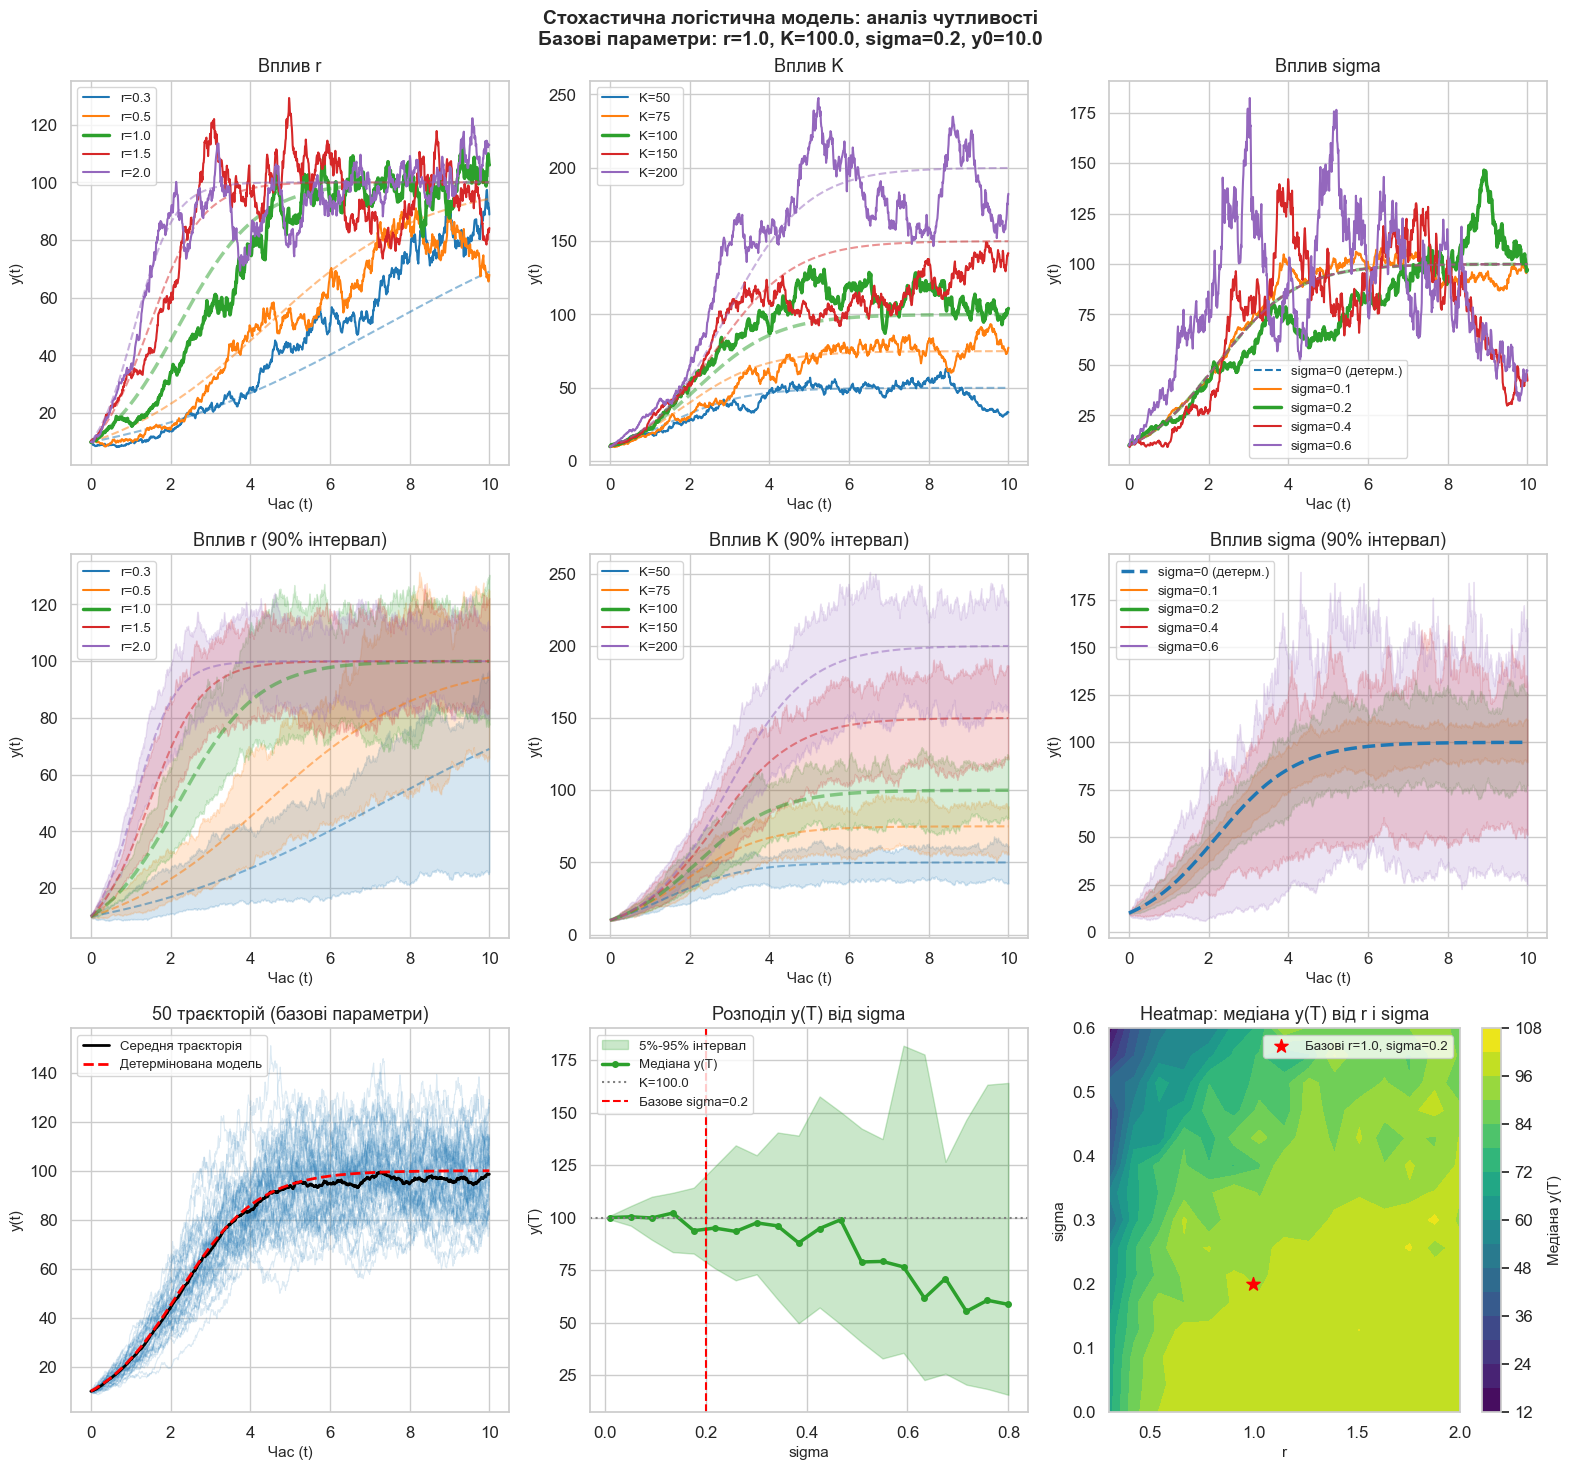

In [ ]:
# Базовi параметри логiстичної стохастичної моделi
r_base  = 1.0
K_base  = 100.0
y0_base = 10.0
sigma_base = 0.2
T_end = 10.0
n_steps = 1000
dt = T_end / n_steps
t_stoch = np.linspace(0, T_end, n_steps)


def euler_maruyama_logistic(r, K, y0, sigma, n_steps, dt, seed=None):
    """Симулює одну траєкторiю стохастичної логiстичної моделi."""
    if seed is not None:
        np.random.seed(seed)
    y = np.zeros(n_steps)
    y[0] = y0
    for i in range(1, n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        drift = r * y[i-1] * (1 - y[i-1] / K) * dt
        diffusion = sigma * y[i-1] * dW
        y[i] = max(y[i-1] + drift + diffusion, 0.0) 
    return y


def logistic_deterministic(r, K, y0):
    """Аналiтичний розв'язок логiстичної моделi."""
    return K / (1 + ((K - y0) / y0) * np.exp(-r * t_stoch))


det_base = logistic_deterministic(r_base, K_base, y0_base)

fig, axes = plt.subplots(3, 3, figsize=(16, 15))
fig.suptitle(
    "Стохастична логiстична модель: аналiз чутливостi\n"
    f"Базовi параметри: r={r_base}, K={K_base}, sigma={sigma_base}, y0={y0_base}",
    fontsize=14, fontweight='bold'
)

# рядок 0: одна стохастична траєкторiя + детермiнована

# Вплив r
ax = axes[0, 0]
for i, r_val in enumerate([0.3, 0.5, 1.0, 1.5, 2.0]):
    det_r = logistic_deterministic(r_val, K_base, y0_base)
    stoch_r = euler_maruyama_logistic(r_val, K_base, y0_base, sigma_base, n_steps, dt)
    lw = 2.5 if r_val == r_base else 1.5
    ax.plot(t_stoch, det_r,   color=PALETTE[i], lw=lw, ls='--', alpha=0.5)
    ax.plot(t_stoch, stoch_r, color=PALETTE[i], lw=lw, label=f'r={r_val}')
ax.set_title("Вплив r")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# Вплив K
ax = axes[0, 1]
for i, K_val in enumerate([50, 75, 100, 150, 200]):
    det_K = logistic_deterministic(r_base, K_val, y0_base)
    stoch_K = euler_maruyama_logistic(r_base, K_val, y0_base, sigma_base, n_steps, dt)
    lw = 2.5 if K_val == K_base else 1.5
    ax.plot(t_stoch, det_K,   color=PALETTE[i], lw=lw, ls='--', alpha=0.5)
    ax.plot(t_stoch, stoch_K, color=PALETTE[i], lw=lw, label=f'K={K_val}')
ax.set_title("Вплив K")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# Вплив sigma
ax = axes[0, 2]
for i, sig in enumerate([0.0, 0.1, 0.2, 0.4, 0.6]):
    lw = 2.5 if sig == sigma_base else 1.5
    if sig == 0.0:
        ax.plot(t_stoch, det_base, color=PALETTE[i], lw=lw, ls='--', label='sigma=0 (детерм.)')
    else:
        stoch_s = euler_maruyama_logistic(r_base, K_base, y0_base, sig, n_steps, dt)
        ax.plot(t_stoch, det_base, color=PALETTE[i], lw=lw, ls='--', alpha=0.5)
        ax.plot(t_stoch, stoch_s,  color=PALETTE[i], lw=lw, label=f'sigma={sig}')
ax.set_title("Вплив sigma")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# рядок 1: 90% довiрчий iнтервал

# Вплив r
ax = axes[1, 0]
for i, r_val in enumerate([0.3, 0.5, 1.0, 1.5, 2.0]):
    paths = np.array([
        euler_maruyama_logistic(r_val, K_base, y0_base, sigma_base, n_steps, dt)
        for _ in range(50)
    ])
    det_r = logistic_deterministic(r_val, K_base, y0_base)
    p5  = np.percentile(paths, 5,  axis=0)
    p95 = np.percentile(paths, 95, axis=0)
    lw = 2.5 if r_val == r_base else 1.5
    ax.fill_between(t_stoch, p5, p95, alpha=0.18, color=PALETTE[i])
    ax.plot(t_stoch, det_r, color=PALETTE[i], lw=lw, ls='--', alpha=0.5)
    ax.plot([], [], color=PALETTE[i], lw=lw, label=f'r={r_val}')
ax.set_title("Вплив r (90% iнтервал)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# Вплив K
ax = axes[1, 1]
for i, K_val in enumerate([50, 75, 100, 150, 200]):
    paths = np.array([
        euler_maruyama_logistic(r_base, K_val, y0_base, sigma_base, n_steps, dt)
        for _ in range(50)
    ])
    det_K = logistic_deterministic(r_base, K_val, y0_base)
    p5  = np.percentile(paths, 5,  axis=0)
    p95 = np.percentile(paths, 95, axis=0)
    lw = 2.5 if K_val == K_base else 1.5
    ax.fill_between(t_stoch, p5, p95, alpha=0.18, color=PALETTE[i])
    ax.plot(t_stoch, det_K, color=PALETTE[i], lw=lw, ls='--', alpha=0.5)
    ax.plot([], [], color=PALETTE[i], lw=lw, label=f'K={K_val}')
ax.set_title("Вплив K (90% iнтервал)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# Вплив sigma
ax = axes[1, 2]
for i, sig in enumerate([0.0, 0.1, 0.2, 0.4, 0.6]):
    if sig == 0.0:
        ax.plot(t_stoch, det_base, color=PALETTE[i], lw=2.5, ls='--', label='sigma=0 (детерм.)')
    else:
        paths = np.array([
            euler_maruyama_logistic(r_base, K_base, y0_base, sig, n_steps, dt)
            for _ in range(50)
        ])
        p5  = np.percentile(paths, 5,  axis=0)
        p95 = np.percentile(paths, 95, axis=0)
        lw = 2.5 if sig == sigma_base else 1.5
        ax.fill_between(t_stoch, p5, p95, alpha=0.18, color=PALETTE[i])
        ax.plot([], [], color=PALETTE[i], lw=lw, label=f'sigma={sig}')
ax.set_title("Вплив sigma (90% iнтервал)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# 50 траєкторiй
ax = axes[2, 0]
many_paths = np.array([
    euler_maruyama_logistic(r_base, K_base, y0_base, sigma_base, n_steps, dt)
    for _ in range(50)
])
for path in many_paths:
    ax.plot(t_stoch, path, color=PALETTE[0], alpha=0.15, lw=0.8)
ax.plot(t_stoch, many_paths.mean(axis=0), color='black', lw=2.0, label='Середня траєкторiя')
ax.plot(t_stoch, det_base, color='red', lw=2.0, ls='--', label='Детермiнована модель')
ax.set_title("50 траєкторiй (базовi параметри)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("y(t)")
ax.legend()

# Розподiл y(T) вiд sigma
ax = axes[2, 1]
sigma_range = np.linspace(0.01, 0.8, 20)

median_vals = []
p5_vals  = []
p95_vals = []

for sig in sigma_range:
    paths = np.array([
        euler_maruyama_logistic(r_base, K_base, y0_base, sig, n_steps, dt)[-1]
        for _ in range(50)
    ])
    median_vals.append(np.median(paths))
    p5_vals.append(np.percentile(paths, 5))
    p95_vals.append(np.percentile(paths, 95))

ax.fill_between(sigma_range, p5_vals, p95_vals, alpha=0.25, color=PALETTE[2], label='5%-95% iнтервал')
ax.plot(sigma_range, median_vals, color=PALETTE[2], lw=2.5, marker='o', markersize=4, label='Медiана y(T)')
ax.axhline(K_base, color='gray', ls=':', lw=1.5, label=f'K={K_base}')
ax.axvline(sigma_base, color='red', ls='--', lw=1.5, label=f'Базове sigma={sigma_base}')
ax.set_title("Розподiл y(T) вiд sigma")
ax.set_xlabel("sigma")
ax.set_ylabel("y(T)")
ax.legend()

# Heatmap
ax = axes[2, 2]
r_grid     = np.linspace(0.3, 2.0, 15) 
sigma_grid = np.linspace(0.0, 0.6, 15)
Z = np.zeros((len(sigma_grid), len(r_grid)))

for si, sig in enumerate(sigma_grid):
    for ri, r_v in enumerate(r_grid):
        paths = np.array([
            euler_maruyama_logistic(r_v, K_base, y0_base, sig, n_steps, dt)[-1]
            for _ in range(50)
        ])
        Z[si, ri] = np.median(paths)      

im = ax.contourf(r_grid, sigma_grid, Z, levels=15, cmap='viridis')
plt.colorbar(im, ax=ax, label='Медiана y(T)')
ax.scatter(r_base, sigma_base, color='red', s=100, zorder=5,
           marker='*', label=f'Базовi r={r_base}, sigma={sigma_base}')
ax.set_title("Heatmap: медiана y(T) вiд r i sigma")
ax.set_xlabel("r")
ax.set_ylabel("sigma")
ax.legend()

plt.tight_layout()
plt.show()

#### Висновки: стохастична логiстична модель

**Вплив r:**
- При малих r (0.3, 0.5) популяцiя повiльно зростає i не досягає K за час T=10 - одна траєкторiя може сильно вiдхилятись вiд детермiнованої. 90% iнтервали для малих r значно ширшi - система довше перебуває у фазi зростання де шум накопичується.
- При великих r (1.5, 2.0) система швидко виходить на плато бiля K.
- При виході на плато ширина 90% інтервалу збільшується.

**Вплив K:**
- Мiсткiсть середовища лiнiйно зсуває рiвноважне значення популяцiї.
- Абсолютний розкид (ширина інтервалу) зростає з K, але вiдносний розкид залишається схожим - система масштабується пропорцiйно.

**Вплив sigma:**
- При sigma=0 маємо єдину гладку детермiновану криву. Вже при sigma=0.2 (базове значення) траєкторiя помiтно вiдхиляється, діапазон розширюється.
- При sigma=0.6 діапазон настiльки широкий що популяцiя може як перевищити K так i впасти майже до нуля - система втрачає передбачуванiсть.

**Розподiл y(T) вiд sigma:**
- До sigma~0.3 медiана тримається бiля K=100 - система стiйка до шуму.
- Пiсля sigma~0.4 медiана починає падати нижче K - сильний шум систематично зменшує фiнальне значення популяцiї.

**Heatmap (медiана y(T) вiд r i sigma):**
- При r < 0.7 i sigma > 0.3 медiана рiзко падає (темна зона) - небезпечна комбiнацiя для популяції.


---
### 1.2 Економiчнi процеси: модель EOQ iз стохастичним попитом

Детермiнована модель:
$$TC(Q) = \frac{D}{Q}S + \frac{Q}{2}H, \quad Q^* = \sqrt{\frac{2DS}{H}}$$

Стохастична модифiкацiя: $D \sim N(\mu_D, \sigma_D)$

| Параметр | Опис | Базове значення |
|---|---|---|
| $\mu_D$ | Середнiй попит | 1000 |
| $S$ | Вартiсть замовлення | 50 |
| $H$ | Вартiсть зберiгання | 2 |
| $\sigma_D$ | Стандартне вiдхилення попиту | 200 |

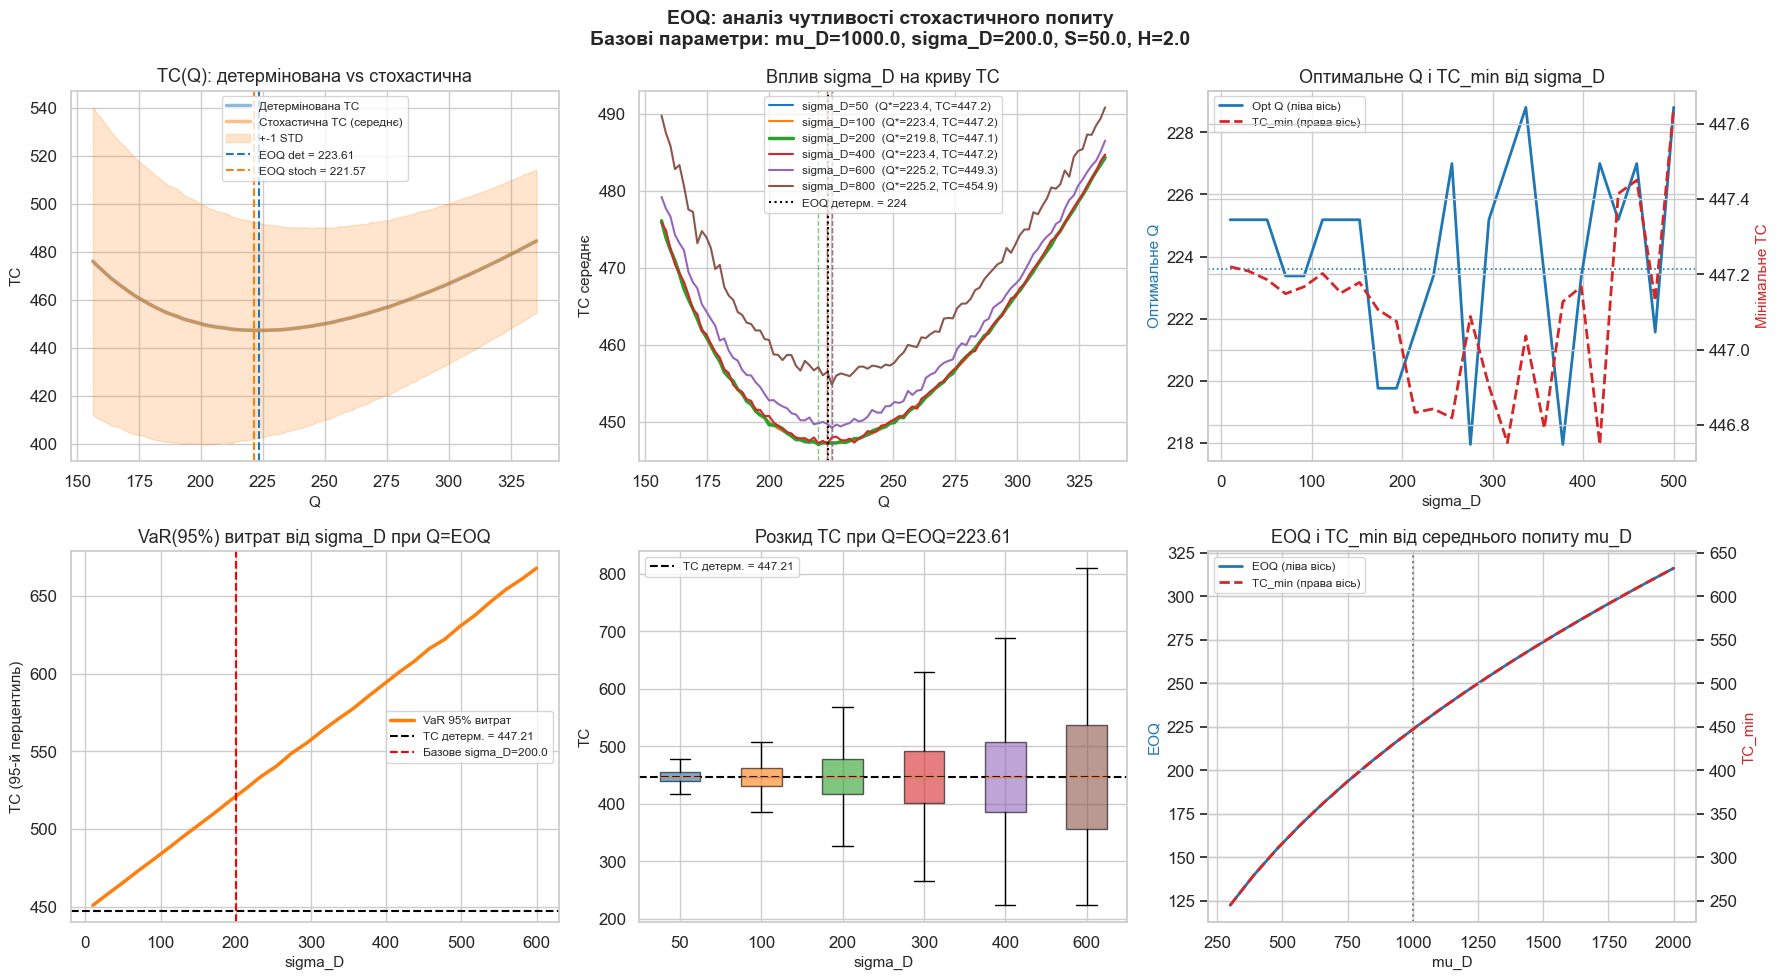

Порiвняння детермiнованої та стохастичної EOQ

EOQ детермiнований Q*:            223.61
EOQ стохастичний Q*:              221.57

TC(Q* det)  - детерм. модель:     447.21
TC(Q* det)  - стохаст. модель:    447.08
TC(Q* stoch)- стохаст. модель:    447.31

Рiзниця мiж Q*:                   2.03
Втрати вiд використання det Q*:   -0.23


In [ ]:
# Базовi параметри EOQ
mu_D_base = 1000.0
S_base = 50.0
H_base = 2.0
sigma_D_base = 200.0
N_SIM = 100000

np.random.seed(41)

def eoq_deterministic(D, S, H):
    return math.sqrt((2 * D * S) / H)


def tc_deterministic(Q, D, S, H):
    return (D / Q) * S + (Q / 2) * H


def tc_stochastic_mean(Q, mu_D, sigma_D, S, H, n_sim=N_SIM):
    """Середнi витрати при випадковому попитi (метод Монте-Карло)."""
    D_samples = np.maximum(np.random.normal(mu_D, sigma_D, n_sim), 1.0)
    tc_samples = (D_samples / Q) * S + (Q / 2) * H
    return tc_samples.mean(), tc_samples.std()


Q_eoq_det = eoq_deterministic(mu_D_base, S_base, H_base)
Q_range = np.linspace(Q_eoq_det * 0.7, Q_eoq_det * 1.5, 100)

tc_det = np.array([tc_deterministic(Q, mu_D_base, S_base, H_base) for Q in Q_range])
tc_stoch_mean = []
tc_stoch_std  = []
for Q in Q_range:
    m, s = tc_stochastic_mean(Q, mu_D_base, sigma_D_base, S_base, H_base)
    tc_stoch_mean.append(m)
    tc_stoch_std.append(s)
tc_stoch_mean = np.array(tc_stoch_mean)
tc_stoch_std  = np.array(tc_stoch_std)

Q_opt_stoch = Q_range[np.argmin(tc_stoch_mean)]


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "EOQ: аналiз чутливостi стохастичного попиту\n"
    f"Базовi параметри: mu_D={mu_D_base}, sigma_D={sigma_D_base}, S={S_base}, H={H_base}",
    fontsize=14, fontweight='bold'
)

#  Базове порiвняння детерм. i стохаст.
ax = axes[0, 0]
ax.plot(Q_range, tc_det, color=PALETTE[0], lw=2.5, alpha=0.5, label='Детермiнована TC')
ax.plot(Q_range, tc_stoch_mean, color=PALETTE[1], lw=2.5, alpha=0.5, label='Стохастична TC (середнє)')
ax.fill_between(Q_range, tc_stoch_mean - tc_stoch_std, tc_stoch_mean + tc_stoch_std,
                alpha=0.2, color=PALETTE[1], label='+-1 STD')
ax.axvline(Q_eoq_det, color=PALETTE[0], ls='--', label=f'EOQ det = {Q_eoq_det:.2f}')
ax.axvline(Q_opt_stoch, color=PALETTE[1], ls='--', label=f'EOQ stoch = {Q_opt_stoch:.2f}')
ax.set_title("TC(Q): детермiнована vs стохастична")
ax.set_xlabel("Q")
ax.set_ylabel("TC")
ax.legend(fontsize=8.5)

# Вплив sigma_D на TC
ax = axes[0, 1]
sigma_D_vals = [50, 100, 200, 400, 600, 800]
for i, sig_D in enumerate(sigma_D_vals):
    tc_s = []
    for Q in Q_range:
        m, _ = tc_stochastic_mean(Q, mu_D_base, sig_D, S_base, H_base)
        tc_s.append(m)
    tc_s = np.array(tc_s)
    Q_opt = Q_range[np.argmin(tc_s)]
    tc_opt = tc_s[np.argmin(tc_s)]
    lw = 2.5 if sig_D == sigma_D_base else 1.5
    ax.plot(Q_range, tc_s, color=PALETTE[i], lw=lw,
            label=f'sigma_D={sig_D}  (Q*={Q_opt:.1f}, TC={tc_opt:.1f})')
    ax.axvline(Q_opt, color=PALETTE[i], ls='--', lw=1.0, alpha=0.6)
ax.axvline(Q_eoq_det, color='black', ls=':', lw=1.5, label=f'EOQ детерм. = {Q_eoq_det:.0f}')
ax.set_title("Вплив sigma_D на криву TC")
ax.set_xlabel("Q")
ax.set_ylabel("TC середнє")
ax.legend(fontsize=8.5)

# Вплив sigma_D на оптимальне Q i TC_min
ax = axes[0, 2]
sigma_D_range = np.linspace(10, 500, 25)
Q_opt_vals = []
tc_min_vals = []
for sig_D in sigma_D_range:
    tc_s = []
    for Q in Q_range:
        m, _ = tc_stochastic_mean(Q, mu_D_base, sig_D, S_base, H_base, n_sim=N_SIM)
        tc_s.append(m)
    tc_s = np.array(tc_s)
    Q_opt_vals.append(Q_range[np.argmin(tc_s)])
    tc_min_vals.append(tc_s.min())
ax2 = ax.twinx()
ax.plot(sigma_D_range, Q_opt_vals, color=PALETTE[0], lw=2.0, label='Opt Q (лiва вiсь)')
ax2.plot(sigma_D_range, tc_min_vals, color=PALETTE[3], lw=2.0, ls='--', label='TC_min (права вiсь)')
ax.axhline(Q_eoq_det, color=PALETTE[0], ls=':', lw=1.2)
ax.set_xlabel("sigma_D")
ax.set_ylabel("Оптимальне Q", color=PALETTE[0])
ax2.set_ylabel("Мiнiмальне TC", color=PALETTE[3])
ax.set_title("Оптимальне Q i TC_min вiд sigma_D")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5)

# VaR витрат вiд sigma_D
ax = axes[1, 0]
sigma_D_range_var = np.linspace(10, 600, 30)
var95_vals = []
tc_det_at_eoq = tc_deterministic(Q_eoq_det, mu_D_base, S_base, H_base)
for sig_D in sigma_D_range_var:
    D_samples = np.maximum(np.random.normal(mu_D_base, sig_D, N_SIM), 1.0)
    tc_samples = (D_samples / Q_eoq_det) * S_base + (Q_eoq_det / 2) * H_base
    var95_vals.append(np.percentile(tc_samples, 95))
ax.plot(sigma_D_range_var, var95_vals, color=PALETTE[1], lw=2.5, label='VaR 95% витрат')
ax.axhline(tc_det_at_eoq, color='black', ls='--', lw=1.5, label=f'TC детерм. = {tc_det_at_eoq:.2f}')
ax.axvline(sigma_D_base, color='red', ls='--', lw=1.5, label=f'Базове sigma_D={sigma_D_base}')
ax.set_title("VaR(95%) витрат вiд sigma_D при Q=EOQ")
ax.set_xlabel("sigma_D")
ax.set_ylabel("TC (95-й перцентиль)")
ax.legend(fontsize=8.5)

# Boxplot TC для рiзних sigma_D
ax = axes[1, 1]
sigma_D_box = [50, 100, 200, 300, 400, 600]
box_data = []
for sig_D in sigma_D_box:
    D_samples = np.maximum(np.random.normal(mu_D_base, sig_D, N_SIM), 1.0)
    box_data.append((D_samples / Q_eoq_det) * S_base + (Q_eoq_det / 2) * H_base)
bp = ax.boxplot(box_data, labels=sigma_D_box, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(tc_det_at_eoq, color='black', ls='--', lw=1.5, label=f'TC детерм. = {tc_det_at_eoq:.2f}')
ax.set_title(f"Розкид TC при Q=EOQ={Q_eoq_det:.2f}")
ax.set_xlabel("sigma_D")
ax.set_ylabel("TC")
ax.legend(fontsize=8.5)

# Вплив mu_D на EOQ та TC_min
ax = axes[1, 2]
mu_D_range = np.linspace(300, 2000, 20)
eoq_vals_det  = [eoq_deterministic(mu, S_base, H_base) for mu in mu_D_range]
tc_vals_det   = [tc_deterministic(eoq_deterministic(mu, S_base, H_base), mu, S_base, H_base)
                 for mu in mu_D_range]
ax2 = ax.twinx()
ax.plot(mu_D_range, eoq_vals_det, color=PALETTE[0], lw=2.0, label='EOQ (лiва вiсь)')
ax2.plot(mu_D_range, tc_vals_det, color=PALETTE[3], lw=2.0, ls='--', label='TC_min (права вiсь)')
ax.axvline(mu_D_base, color='gray', ls=':', lw=1.5)
ax.set_xlabel("mu_D")
ax.set_ylabel("EOQ", color=PALETTE[0])
ax2.set_ylabel("TC_min", color=PALETTE[3])
ax.set_title("EOQ i TC_min вiд середнього попиту mu_D")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8.5)

plt.tight_layout()
plt.show()


print("Порiвняння детермiнованої та стохастичної EOQ")
print()
print(f"EOQ детермiнований Q*: {Q_eoq_det:.2f}")
print(f"EOQ стохастичний Q*:  {Q_opt_stoch:.2f}")
print()
tc_det_val = tc_deterministic(Q_eoq_det, mu_D_base, S_base, H_base)
tc_at_det_eoq, _  = tc_stochastic_mean(Q_eoq_det,    mu_D_base, sigma_D_base, S_base, H_base)
tc_at_stoch_opt, _ = tc_stochastic_mean(Q_opt_stoch, mu_D_base, sigma_D_base, S_base, H_base)
print(f"TC(Q* det)  - детерм. модель: {tc_det_val:.2f}")
print(f"TC(Q* det)  - стохаст. модель: {tc_at_det_eoq:.2f}")
print(f"TC(Q* stoch)- стохаст. модель: {tc_at_stoch_opt:.2f}")
print()
print(f"Рiзниця мiж Q*: {abs(Q_opt_stoch - Q_eoq_det):.2f}")
print(f"Втрати вiд використання det Q*:{tc_at_det_eoq - tc_at_stoch_opt:.2f}")


#### Висновки: EOQ iз стохастичним попитом

**Q\* детермiнований vs стохастичний:**
Обидва оптимуми збiгаються (рiзниця 2.03) - це теоретично очiкувано, оскiльки
E[TC(Q)] мiнiмiзується при тому самому Q*. Невизначенiсть попиту не змiщує
оптимальний розмiр замовлення.

**Вплив sigma_D:**
Зростання sigma_D пiднiмає криву TC вгору, але не змiщує її мiнiмум.
Тобто компанiя платить бiльше в середньому, але оптимальна стратегiя не змiнюється.

**VaR(95%) - вартiсть пiд ризиком:**
VaR(95%) показує максимальнi витрати у найгiрших 5% сценарiїв - тобто
"скiльки може коштувати невдача". Зростає лiнiйно зi збiльшенням sigma_D:  
при базовому sigma_D=200 вiн вже на ~100 одиниць перевищує детермiнований
TC=447, а при sigma_D=600 компанiя в найгiршому випадку може заплатити вдвiчi бiльше нiж очiкувала.  
Саме цей ризик повнiстю iгнорує класична детермiнована модель.

---
### 1.3 Соцiальнi процеси: стохастична модель соцiальної динамiки

$$dx = k\,x(1-x)(x-\theta)\,dt + \sigma\,dW(t)$$

| Параметр | Опис | Базове значення |
|---|---|---|
| $k$ | Швидкiсть динамiки | 1.0 |
| $\theta$ | Критичний порiг | 0.3 |
| $\sigma$ | Iнтенсивнiсть шуму | 0.05 |
| $x_0$ | Початкова частка пiдтримки | 0.1 |

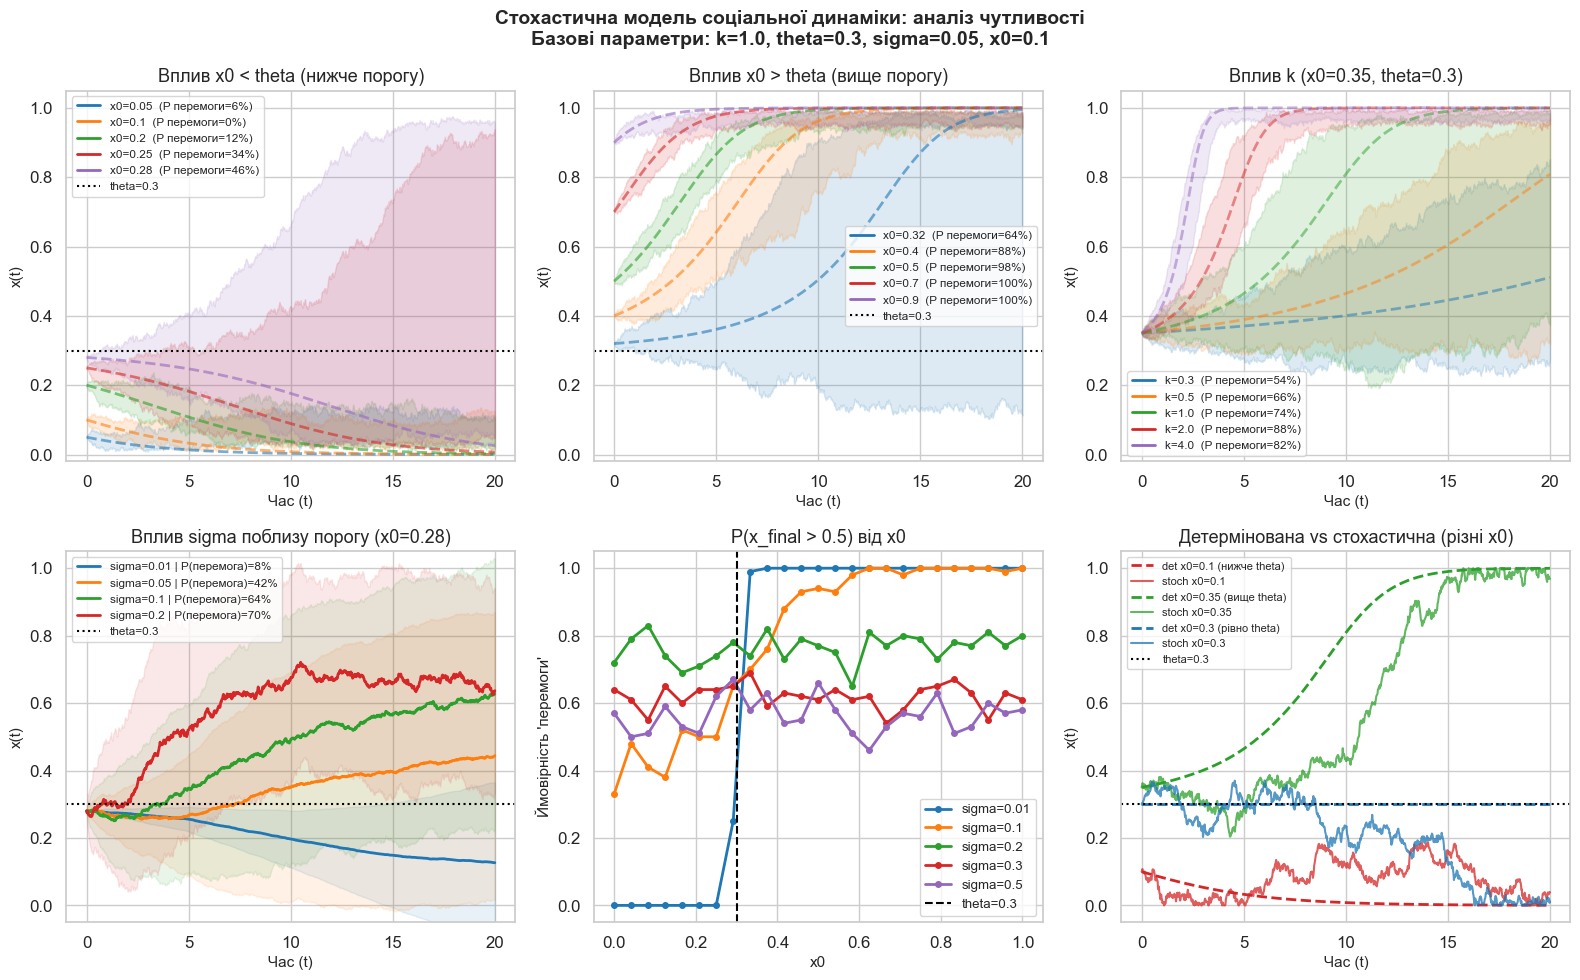

In [63]:
# Параметри соцiальної моделi
k_base     = 1.0
theta_base = 0.3
sigma_soc_base = 0.05
x0_base    = 0.1
T_soc = 20.0
n_soc = 1000
dt_soc = T_soc / n_soc
t_soc = np.linspace(0, T_soc, n_soc)

np.random.seed(43)

def euler_maruyama_social(k, theta, x0, sigma, n_steps, dt):
    """Симулює одну траєкторiю стохастичної моделi соцiальної динамiки."""
    x = np.zeros(n_steps)
    x[0] = x0
    for i in range(1, n_steps):
        dW = np.random.normal(0, np.sqrt(dt))
        f = k * x[i-1] * (1 - x[i-1]) * (x[i-1] - theta)
        x[i] = np.clip(x[i-1] + f * dt + sigma * dW, 0.0, 1.0)
    return x


def social_rhs(t, state, k, theta):
    xv = state[0]
    return [k * xv * (1 - xv) * (xv - theta)]


def solve_social_deterministic(k, theta, x0):
    """Детермiнований розв'язок"""
    sol = solve_ivp(
        lambda t, state: social_rhs(t, state, k, theta),
        (0, T_soc), [x0], t_eval=t_soc, method='RK45'
    )
    return sol.y[0]


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Стохастична модель соцiальної динамiки: аналiз чутливостi\n"
    f"Базовi параметри: k={k_base}, theta={theta_base}, sigma={sigma_soc_base}, x0={x0_base}",
    fontsize=14, fontweight='bold'
)

# Вплив x0 (нижче порогу) 
ax = axes[0, 0]
x0_vals_below = [0.05, 0.1, 0.2, 0.25, 0.28]
for i, x0_v in enumerate(x0_vals_below):
    x_det = solve_social_deterministic(k_base, theta_base, x0_v)
    paths = np.array([
        euler_maruyama_social(k_base, theta_base, x0_v, sigma_soc_base, n_soc, dt_soc)
        for _ in range(50)
    ])
    p_win = (paths[:, -1] > 0.5).mean() * 100
    p25 = np.percentile(paths, 25, axis=0)
    p75 = np.percentile(paths, 75, axis=0)
    ax.plot(t_soc, x_det, color=PALETTE[i], lw=2.0, ls='--', alpha=0.6)
    ax.fill_between(t_soc, p25, p75, alpha=0.15, color=PALETTE[i])
    ax.plot([], [], color=PALETTE[i], lw=2.0, label=f'x0={x0_v}  (P перемоги={p_win:.0f}%)')
ax.axhline(theta_base, color='black', ls=':', lw=1.5, label=f'theta={theta_base}')
ax.set_title("Вплив x0 < theta (нижче порогу)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("x(t)")
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=8.5)

# Вплив x0 (вище порогу)
ax = axes[0, 1]
x0_vals_above = [0.32, 0.4, 0.5, 0.7, 0.9]
for i, x0_v in enumerate(x0_vals_above):
    x_det = solve_social_deterministic(k_base, theta_base, x0_v)
    paths = np.array([
        euler_maruyama_social(k_base, theta_base, x0_v, sigma_soc_base, n_soc, dt_soc)
        for _ in range(50)
    ])
    p_win = (paths[:, -1] > 0.5).mean() * 100
    p25 = np.percentile(paths, 25, axis=0)
    p75 = np.percentile(paths, 75, axis=0)
    ax.plot(t_soc, x_det, color=PALETTE[i], lw=2.0, ls='--', alpha=0.6)
    ax.fill_between(t_soc, p25, p75, alpha=0.15, color=PALETTE[i])
    ax.plot([], [], color=PALETTE[i], lw=2.0, label=f'x0={x0_v}  (P перемоги={p_win:.0f}%)')
ax.axhline(theta_base, color='black', ls=':', lw=1.5, label=f'theta={theta_base}')
ax.set_title("Вплив x0 > theta (вище порогу)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("x(t)")
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=8.5)

# Вплив k
ax = axes[0, 2]
k_vals = [0.3, 0.5, 1.0, 2.0, 4.0]
x0_fixed = 0.35
for i, k_v in enumerate(k_vals):
    paths = np.array([
        euler_maruyama_social(k_v, theta_base, x0_fixed, sigma_soc_base, n_soc, dt_soc)
        for _ in range(50)
    ])
    x_det = solve_social_deterministic(k_v, theta_base, x0_fixed)
    p25  = np.percentile(paths, 25,  axis=0)
    p75 = np.percentile(paths, 75, axis=0)
    p_win = (paths[:, -1] > 0.5).mean() * 100
    ax.fill_between(t_soc, p25, p75, alpha=0.15, color=PALETTE[i])
    ax.plot(t_soc, x_det, color=PALETTE[i], lw=2.0, ls='--', alpha=0.5)
    ax.plot([], [], color=PALETTE[i], lw=2.0,
            label=f'k={k_v}  (P перемоги={p_win:.0f}%)')
ax.set_title(f"Вплив k (x0={x0_fixed}, theta={theta_base})")
ax.set_xlabel("Час (t)")
ax.set_ylabel("x(t)")
ax.set_ylim(-0.02, 1.05)
ax.legend(fontsize=8.5)

# Вплив sigma поблизу порогу
ax = axes[1, 0]
x0_near = 0.28 
sigma_soc_vals = [0.01, 0.05, 0.1, 0.2]
for i, sig in enumerate(sigma_soc_vals):
    paths = np.array([
        euler_maruyama_social(k_base, theta_base, x0_near, sig, n_soc, dt_soc)
        for _ in range(50)
    ])
    # Частка траєкторiй що перевалила за 0.5
    survived = (paths[:, -1] > 0.5).mean() * 100
    ax.plot(t_soc, paths.mean(axis=0), color=PALETTE[i], lw=2.0,
            label=f'sigma={sig} | P(перемога)={survived:.0f}%')
    ax.fill_between(t_soc, paths.mean(axis=0) - paths.std(axis=0),
                    paths.mean(axis=0) + paths.std(axis=0), alpha=0.1, color=PALETTE[i])
ax.axhline(theta_base, color='black', ls=':', lw=1.5, label=f'theta={theta_base}')
ax.set_title(f"Вплив sigma поблизу порогу (x0={x0_near})")
ax.set_xlabel("Час (t)")
ax.set_ylabel("x(t)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8.5)

# Ймовiрнiсть "перемоги" вiд x0 при рiзних sigma
ax = axes[1, 1]
x0_scan = np.linspace(0.0, 1.0, 25)
for i, sig in enumerate([0.01, 0.1, 0.2, 0.3, 0.5]):
    p_win = []
    for x0_v in x0_scan:
        paths = np.array([
            euler_maruyama_social(k_base, theta_base, x0_v, sig, n_soc, dt_soc)[-1]
            for _ in range(100)
        ])
        p_win.append((paths > 0.5).mean())
    ax.plot(x0_scan, p_win, color=PALETTE[i], lw=2.0, marker='o', markersize=4,
            label=f'sigma={sig}')
ax.axvline(theta_base, color='black', ls='--', lw=1.5, label=f'theta={theta_base}')
ax.set_title("P(x_final > 0.5) вiд x0")
ax.set_xlabel("x0")
ax.set_ylabel("Ймовiрнiсть 'перемоги'")
ax.legend()

# Детермiнований vs стохастичний: приклад одної симуляцiї
ax = axes[1, 2]
scenarios = [
    (0.1,  'нижче theta', PALETTE[3]),
    (0.35, 'вище theta',  PALETTE[2]),
    (0.30, 'рiвно theta', PALETTE[0]),
]
for x0_v, label, color in scenarios:
    x_det = solve_social_deterministic(k_base, theta_base, x0_v)
    ax.plot(t_soc, x_det, color=color, lw=2.0, ls='--', label=f'det x0={x0_v} ({label})')
    x_stoch = euler_maruyama_social(k_base, theta_base, x0_v, sigma_soc_base, n_soc, dt_soc)
    ax.plot(t_soc, x_stoch, color=color, lw=1.5, alpha=0.75, label=f'stoch x0={x0_v}')
ax.axhline(theta_base, color='black', ls=':', lw=1.5, label=f'theta={theta_base}')
ax.set_title("Детермiнована vs стохастична (рiзнi x0)")
ax.set_xlabel("Час (t)")
ax.set_ylabel("x(t)")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8.0)

plt.tight_layout()
plt.show()

#### Висновки: стохастична модель соцiальної динамiки

**Роль критичного порогу theta:**
Theta є головним роздiлювачем системи. При x0 < theta детермiнована модель
гарантовано веде до 0, при x0 > theta - до 1. Стохастична модель розмиває
цю межу: при x0=0.28 (нижче theta=0.3) дає P перемоги ~34-46% через
випадковi флуктуацiї що можуть перекинути систему через порiг.

**Зона поблизу theta:**
Широкий довiрчий коридор при x0=0.25-0.28 показує зону нестабiльностi -
траєкторiї розходяться у два протилежнi кiнцi (0 або 1) i шум повнiстю
визначає результат.

**Вплив k:**
Бiльше k - швидше система "вирiшує". При k=0.3 система довго коливається
i шум встигає вплинути на результат. При k=4.0 система швидко фiксується,
але P перемоги не є монотонною - при x0 трохи вище theta великий k
"штовхає" сильнiше до 1.

**Вплив sigma поблизу порогу:**
При sigma=0.01 система майже детермiнована - P перемоги лише 8%.
При sigma=0.2 шум регулярно перекидає систему через порiг - P зростає до 70%.
Це показує що у соцiальних системах зовнiшнi випадковi впливи (медiа, подiї)
можуть кардинально змiнити результат навiть при несприятливих початкових умовах.

---
## Завдання 2: Побудова та аналiз портфеля активiв (Монте-Карло)

Активи: TSLA, GOOG, GM  
Данi: iсторичнi через `yfinance`

### 2.1 Збiр та обробка даних

In [ ]:
TICKERS = ['TSLA',  'GM', 'GOOG']

price_data = yf.download(TICKERS, start='2020-01-01', end='2025-01-01',
                         auto_adjust=True, progress=False)['Close']

# Логарифмiчнi щоденнi прибутковостi
log_returns = np.log(price_data / price_data.shift(1)).dropna()

# Рiчна дохiднiсть i волатильнiсть
annual_returns = log_returns.mean() * 252
annual_vol = log_returns.std()  * np.sqrt(252)

print(f"Кiлькiсть спостережень (днiв): {len(log_returns)}")
print()
print("Рiчна дохiднiсть:")
for t in TICKERS:
    print(f"  {t}: {annual_returns[t]:.2%}")
print()
print("Рiчна волатильнiсть:")
for t in TICKERS:
    print(f"  {t}: {annual_vol[t]:.2%}")

Кiлькiсть спостережень (днiв): 1257

Рiчна дохiднiсть:
  TSLA: 53.02%
  GM: 7.86%
  GOOG: 20.61%

Рiчна волатильнiсть:
  TSLA: 67.00%
  GM: 43.19%
  GOOG: 32.41%


### 2.2 Симуляцiя портфельної дохiдностi (Монте-Карло)

In [93]:
# Ваги активiв у портфелi (сума = 1)
weights = np.array([0.4, 0.4, 0.2])  

N_MC = 50000  # кiлькiсть симуляцiй Монте-Карло
np.random.seed(42)

# Симулюємо рiчнi дохiдностi для кожного активу незалежно
sim_returns = np.column_stack([
    np.random.normal(annual_returns[t], annual_vol[t], N_MC)
    for t in TICKERS
])

# Портфельна дохiднiсть
portfolio_returns = sim_returns @ weights

# Ключовi показники
expected_return = portfolio_returns.mean()
portfolio_risk  = portfolio_returns.std()
var_5 = np.percentile(portfolio_returns, 5)   # Value-at-Risk на рiвнi 5%
sharpe = expected_return / portfolio_risk       # Коефiцiєнт Шарпа (без безризикової ставки)

print("Параметри портфеля (TSLA 40%, GM 40%, GOOG 20%)")
print()
print(f"Очiкувана дохiднiсть:     {expected_return:.2%}")
print(f"Ризик (std):              {portfolio_risk:.2%}")
print(f"VaR (5%):                 {var_5:.2%}")
print(f"Коефiцiєнт Шарпа:         {sharpe:.3f}")


Параметри портфеля (TSLA 40%, GM 40%, GOOG 20%)

Очiкувана дохiднiсть:     28.52%
Ризик (std):              32.47%
VaR (5%):                 -24.64%
Коефiцiєнт Шарпа:         0.878


### 2.3 Вiзуалiзацiя та аналiз

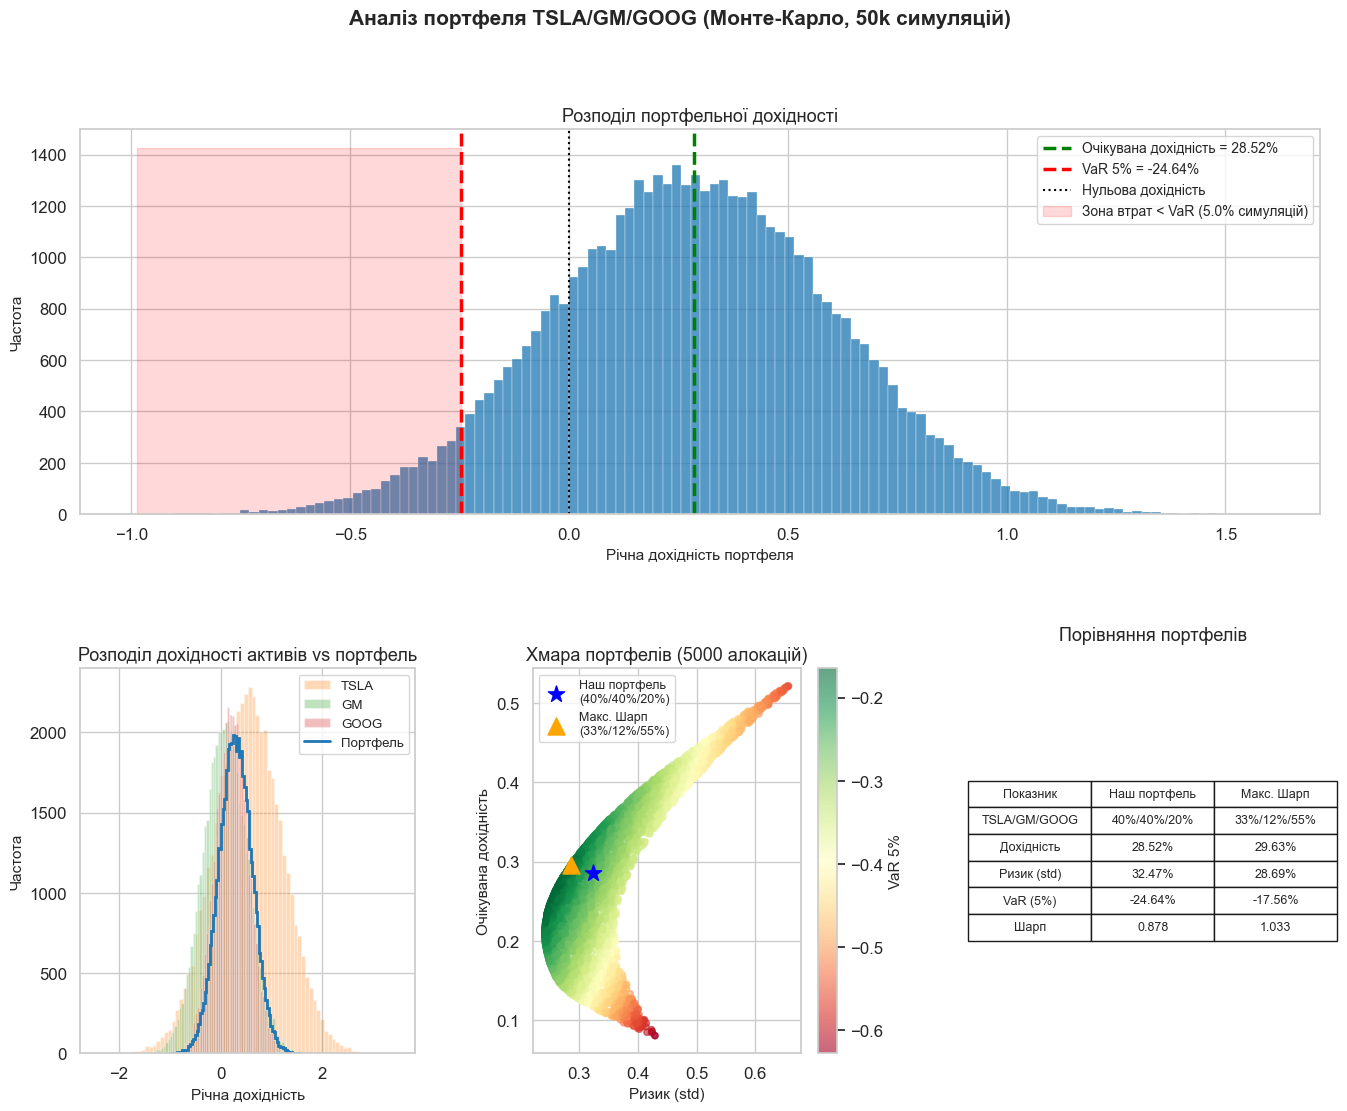


Найкращi ваги за Шарпом: TSLA=32.53%, GOOG=12.42%, GM=55.06%
Коефiцiєнт Шарпа (макс): 1.033 vs наш: 0.878


In [92]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.suptitle(
    "Аналiз портфеля TSLA/GM/GOOG (Монте-Карло, 50k симуляцiй)",
    fontsize=15, fontweight='bold'
)

# Гiстограма розподiлу портфельної дохiдностi
ax1 = fig.add_subplot(gs[0, :])
ax1.hist(portfolio_returns, bins=120, color=PALETTE[0], alpha=0.75, edgecolor='white', lw=0.3)
ax1.axvline(expected_return, color='green', lw=2.5, ls='--',
            label=f'Очiкувана дохiднiсть = {expected_return:.2%}')
ax1.axvline(var_5, color='red', lw=2.5, ls='--',
            label=f'VaR 5% = {var_5:.2%}')
ax1.axvline(0, color='black', lw=1.5, ls=':', label='Нульова дохiднiсть')
ax1.fill_betweenx(
    [0, ax1.get_ylim()[1]],
    portfolio_returns.min(), var_5,
    alpha=0.15, color='red', label=f'Зона втрат < VaR ({(portfolio_returns < var_5).mean():.1%} симуляцiй)'
)
ax1.set_xlabel("Рiчна дохiднiсть портфеля")
ax1.set_ylabel("Частота")
ax1.set_title("Розподiл портфельної дохiдностi")
ax1.legend(fontsize=10)

# Порiвняння iндивiдуальних розподiлiв активiв
ax2 = fig.add_subplot(gs[1, 0])
for i, t in enumerate(TICKERS):
    ax2.hist(sim_returns[:, i], bins=80, alpha=0.3, color=PALETTE[i+1], label=t)
counts, bin_edges = np.histogram(portfolio_returns, bins=80)
ax2.stairs(counts, bin_edges, color=PALETTE[0], lw=2.0, label='Портфель')
ax2.set_xlabel("Рiчна дохiднiсть")
ax2.set_ylabel("Частота")
ax2.set_title("Розподiл дохiдностi активiв vs портфель")
ax2.legend()

# Аналiз рiзних алокацiй
ax3 = fig.add_subplot(gs[1, 1])

# Перебираємо 5000 випадкових алокацiй
np.random.seed(123)
n_portfolios = 5000
all_weights = np.random.dirichlet(np.ones(3), n_portfolios)

port_means = []
port_stds  = []
port_vars  = []
for w in all_weights:
    pr = sim_returns @ w
    port_means.append(pr.mean())
    port_stds.append(pr.std())
    port_vars.append(np.percentile(pr, 5))

port_means = np.array(port_means)
port_stds  = np.array(port_stds)
port_vars  = np.array(port_vars)

# VaR 5%
sc = ax3.scatter(port_stds, port_means, c=port_vars, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax3, label='VaR 5%')

# Наш портфель
ax3.scatter(portfolio_risk, expected_return, color='blue', s=150, zorder=5,
            marker='*', label=f'Наш портфель\n({weights[0]:.0%}/{weights[1]:.0%}/{weights[2]:.0%})')

# Найкращий за Шарпом
sharpe_vals = port_means / port_stds
best_idx = np.argmax(sharpe_vals)
ax3.scatter(port_stds[best_idx], port_means[best_idx], color='orange', s=150,
            marker='^', zorder=5,
            label=f'Макс. Шарп\n({all_weights[best_idx][0]:.0%}/{all_weights[best_idx][1]:.0%}/{all_weights[best_idx][2]:.0%})')

ax3.set_xlabel("Ризик (std)")
ax3.set_ylabel("Очiкувана дохiднiсть")
ax3.set_title("Хмара портфелiв (5000 алокацiй)")
ax3.legend(fontsize=9)

# Таблиця показникiв
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')

best_w = all_weights[best_idx]
best_pr = sim_returns @ best_w

table_data = [
    ['Показник', 'Наш портфель', 'Макс. Шарп'],
    ['TSLA/GM/GOOG',
     f'{weights[0]:.0%}/{weights[1]:.0%}/{weights[2]:.0%}',
     f'{best_w[0]:.0%}/{best_w[1]:.0%}/{best_w[2]:.0%}'],
    ['Дохiднiсть', f'{expected_return:.2%}', f'{best_pr.mean():.2%}'],
    ['Ризик (std)', f'{portfolio_risk:.2%}', f'{best_pr.std():.2%}'],
    ['VaR (5%)', f'{var_5:.2%}', f'{np.percentile(best_pr, 5):.2%}'],
    ['Шарп', f'{sharpe:.3f}', f'{best_pr.mean()/best_pr.std():.3f}'],
]

table = ax4.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.1, 1.6)
ax4.set_title("Порiвняння портфелiв", pad=20)

plt.show()

print(f"\nНайкращi ваги за Шарпом: TSLA={best_w[0]:.2%}, GOOG={best_w[1]:.2%}, GM={best_w[2]:.2%}")
print(f"Коефiцiєнт Шарпа (макс): {sharpe_vals[best_idx]:.3f} vs наш: {sharpe:.3f}")

#### Аналiз та рекомендацiї щодо ребалансування

**Поточний портфель (TSLA 40%, GM 40%, GOOG 20%):**
Очiкувана дохiднiсть 28.52% виглядає привабливо, але ризик 32.47% перевищує рiвень дохiдностi - це ознака агресивного портфеля. VaR(5%) = -24.64%
означає що у 5% найгірших сценарiїв (тобто раз на 20 років) портфель втратить бiльше нiж 24% за рiк.

**Порiвняння з оптимальним за Шарпом (TSLA 33%, GM 12%, GOOG 55%):**
Портфель з максимальним Шарпом (1.033 vs 0.878) дає схожу дохiднiсть
(29.63%) при меншому ризику (28.69%) i кращому VaR (-17.56%). Основна
рiзниця - бiльша частка GOOG i менша GM.

**Рекомендацiї:**
- Зменшити частку GM з 40% до 10-15% - актив дає помiрну дохiднiсть
  але займає надто велику частку
- Збiльшити GOOG до 50-55% - стабiльнiший актив з кращим Шарпом
- Залишити TSLA на рiвнi 30-35% для збереження потенцiалу зростання
- Така алокацiя знизить VaR з -24.64% до приблизно -17%, що є
  суттєвим покращенням для управлiння ризиком

## Завдання 3: Теоретичнi питання

**Якi обмеження має метод Монте-Карло для оцiнки портфельної дохiдностi?**

Головне обмеження - якiсть вхiдних даних. МК генерує сценарiї на основi
iсторичних mu i sigma, але минуле не гарантує майбутнє.   
Також базова версiя симулює активи незалежно, iгноруючи кореляцiї мiж ними - а в кризи активи
зазвичай падають разом.  
Ще одна проблема - нормальний розподiл занижує
ймовiрнiсть екстремальних подiй (криза 2008, COVID).

**Якi iншi методи можна використовувати для аналiзу портфеля?**

Класична оптимiзацiя Марковiца - аналiтично знаходить ефективну границю
без симуляцiй.  
CAPM - оцiнює дохiднiсть через ринковий ризик (beta).   
GARCH-моделi - враховують що волатильнiсть змiнюється з часом, а не є
постiйною як у нас.  
Black-Litterman модель - дозволяє поєднати ринкову рiвновагу 
з власними прогнозами аналiтика

**Чи можна використовувати iншi розподiли?**

Так, i це було б точнiше. t-розподiл Стьюдента має товстi хвости i краще
описує реальнi фiнансовi данi - екстремальнi падiння трапляються частiше
нiж передбачає нормальний розподiл.  
Аргумент проти - складнiше оцiнювати параметри i пояснювати результати.

**Як врахувати невизначенiсть щодо майбутнiх дохiдностей?**

Найпростiший спосiб - сценарний аналiз: задати кiлька макроекономiчних
сценарiїв (зростання, стагнацiя, рецесiя) i для кожного свої параметри.   
Бiльш формально - байєсiвський пiдхiд де самi mu i sigma є випадковими
величинами з певним розподiлом.  
На практицi також роблять стрес-тести -
перевiряють портфель на конкретних iсторичних кризах.

**Якi альтернативнi методи оцiнки ризику, крiм VaR?**

CVaR (Expected Shortfall) - на рiвнi 5% показує середнi втрати у тих самих найгiрших 5% сценарiїв
де VaR лише фiксує межу. Це чеснiше нiж VaR бо враховує наскiльки погано може
бути за цiєю межею.  
Maximum Drawdown - максимальне падiння вiд пiку до дна, iнтуїтивно зрозумiло будь-якому iнвестору.  
Коефiцiєнт Сортiно - схожий на Шарп але враховує тiльки негативнi вiдхилення, що справедливiше.